In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


## Simulaatio

In [4]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

In [5]:
list_AC_stark_vals=[np.float64(-0.06854670085965597), np.float64(-0.0791553748461747), np.float64(-0.09052059521500729), np.float64(-0.10284236196615382), np.float64(-0.11592067509961422), np.float64(-0.12985553461538857), np.float64(-0.14474694051347667), np.float64(-0.16039489279387883), np.float64(-0.17729939145659485), np.float64(-0.19496043650162476), np.float64(-0.21367802792896848), np.float64(-0.2334521657386262), np.float64(-0.2542828499305977), np.float64(-0.2759700805048832), np.float64(-0.2989138574614825), np.float64(-0.3229141808003959), np.float64(-0.34777105052162305), np.float64(-0.373784466625164), np.float64(-0.40095442911101903), np.float64(-0.4288809379791878)]

In [6]:
def sim_pulse(f_d,f_supp,A,evolution,dim,f_rabi,K=60,t_ramp=5,verbose=False,p=1):
    T_floquet = 2*np.pi/(f_d) #Floquet-jakson pituus
    dt = T_floquet/K #Diskretoidaan aika-avaruus siten, että Floquet-jakson pituus on K aikapistettä

    t_gap=np.pi/(f_supp)
    t_ramp_new=t_ramp-t_gap/2

    phi=t_gap*f_d
    
    N_edge1 = int((t_ramp_new*2+t_gap/2)/dt)
    N_edge2 = int((t_ramp_new*2-t_gap/2)/dt)

    N_pulse=int(2*np.pi/(f_rabi*dt)) #Määritellään pulssin pituus arvatun Rabi-taajuuden perusteella

    #Kokonainen pulssi rampin aikakehityksen sekä Floquet-operaattorin laskemista varten
    pulse1 = pulses.Pulse(f_d,f_supp,[pulses.gaussian(t_ramp_new*2-t_gap/2,t_ramp_new/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new/2)],[N_edge2,N_pulse,N_edge1],time_unit=dt,offset_input=-phi/2)
    pulse2 = pulses.Pulse(f_d,f_supp,[pulses.gaussian(t_ramp_new*2+t_gap/2,t_ramp_new/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new/2)],[N_edge1,N_pulse,N_edge2],time_unit=dt,offset_input=phi/2)

    combined_pulse = pulse1.raw + pulse2.raw
    m = 2*np.abs(np.cos(phi/2))

    if verbose:
        plt.figure()
        plt.plot(pulse1.time_vals,combined_pulse/m)
        plt.plot(pulse1.time_vals,(pulse1.envelope + pulse2.envelope)/2)
        plt.xlabel("Aika (ms)")
        plt.xlim([5,10])
        plt.ylabel("Normalisoitu amplitudi")
        plt.title("Yhdistetty pulssi")
        plt.show()

    U_floquet=evolution.U_floquet(A*combined_pulse[N_edge1:N_edge1+K]/m,dt)
    U_floquet=np.linalg.matrix_power(U_floquet,p)

    #Alustetaan kubitin tila perustilaan
    psi_eig_accum = np.zeros(dim, dtype=complex)
    psi_eig_accum[0] = 1

    #Lopulliset todennäköisyydet eripituisten pulssien jälkeen
    last_vals=[]

    for i in range(0, N_edge1): #Aikakehitys nousevalle rampille
        psi_eig_accum = evolution.U(A*combined_pulse[i]/m, dt) @ psi_eig_accum

    #Simuloitujen pulssien määrä/K koska jokainen simulaatio edistää tilaa yhden Floquet-jakson (K*dt)
    N_sim=int(N_pulse/(K*p))

    #Simulaatio pulsseille
    for k in range(0,N_sim):
        psi_eig = psi_eig_accum

        #Laskevan rampin simulaatio
        pulse1 = pulses.Pulse(f_d,f_supp,[pulses.gaussian(t_ramp*2-t_gap/2,t_ramp_new/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new/2)],[N_edge2,K*p*k,N_edge1],time_unit=dt,offset_input=-phi/2)
        pulse2 = pulses.Pulse(f_d,f_supp,[pulses.gaussian(t_ramp*2+t_gap/2,t_ramp_new/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new/2)],[N_edge1,K*p*k,N_edge2],time_unit=dt,offset_input=phi/2)
        combined_pulse = pulse1.raw + pulse2.raw

        remainder = len(combined_pulse)-N_edge1-K*p*k

        for i in range(0, remainder): #Aikakehitys
            psi_eig = evolution_eigenbasis.U(A*combined_pulse[N_edge1+K*p*k+i]/m, dt) @ psi_eig
        last_vals.append(np.abs(psi_eig)**2)
        psi_eig_accum = U_floquet @ psi_eig_accum #Kehitetään kubitin tilaa yhdellä Floquet-jaksolla

    #e- ja f-tasojen lopulliset todennäköisyydet
    e_vals = np.array([a[1] for a in last_vals])
    f_vals = np.array([a[2] for a in last_vals])

    #e-tason suurin todennäköisyys
    excited_max=max(e_vals)
    #f-tason suurin todennäköisyys pulssille, jolla e-taso saavuttaa suurimman arvonsa
    f_max=max(f_vals)

    #Simuloitujen pulssien pituudet, plottausta varten
    pulse_times=np.arange(0,N_sim)*K*p*dt + 2*t_ramp + t_gap

    #Pulssin pituus määritettynä maksimiarvon sijainnin perusteella
    index = np.argmax(e_vals)
    T_pulse = pulse_times[index]
    
    return (excited_max,f_max,T_pulse,last_vals,pulse_times)

def find_params(f_d,A,evolution,f_rabi,AC_stark,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]

    for i in range(min_range,max_range):
        delta=AC_stark+i/scale #AC-stark siirtymä
        AC_stark_vals.append(delta)

        if A < 8:
            sim_vals = sim_pulse(f_d,f_ef/3+delta,A,evolution,dim,f_rabi,t_ramp=5,p=5)
        else:
            sim_vals = sim_pulse(f_d,f_ef/3+delta,A,evolution,dim,f_rabi,t_ramp=5)
        
        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("delta=ω_ef-ω_suppressed (GHz)")
    plt.ylabel("Suurin e-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    AC_stark=AC_stark_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(AC_stark,pi_pulse,[e_max,f_max],max_e_vals)

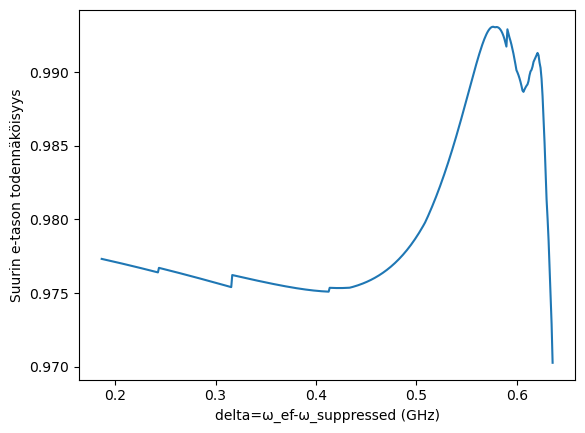

Amplitudi (GHz): 5.862378319584177
AC-stark siirtymä (GHz): 0.5765948637445237
E-tason suurin todennäköisyys: 0.9933070518626157
Pulssin pituus (ns): 248.9538826788503
Rabi-taajuus (fourier):  0.0021855491816959614


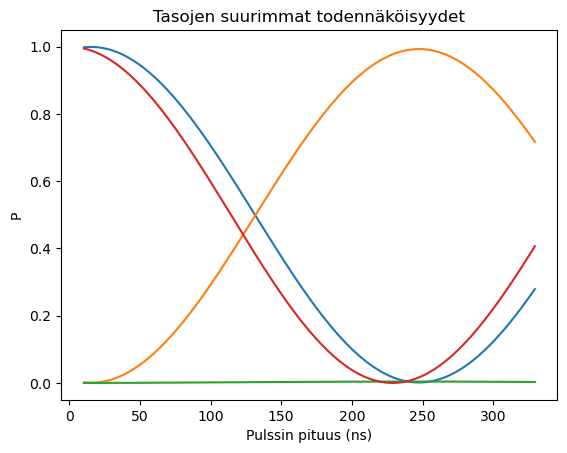

---------------------------------------------


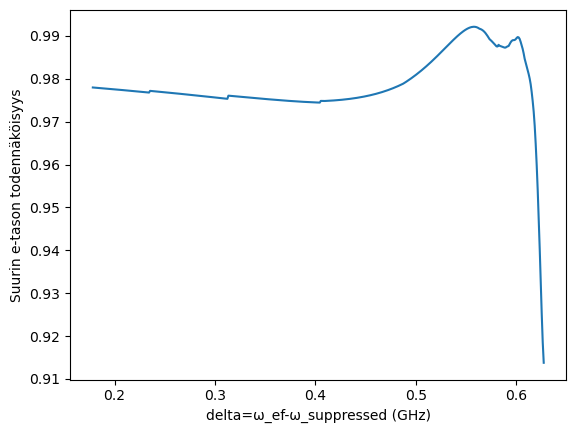

Amplitudi (GHz): 6.291660027196749
AC-stark siirtymä (GHz): 0.557319407181995
E-tason suurin todennäköisyys: 0.9921466968670011
Pulssin pituus (ns): 204.46645373082308
Rabi-taajuus (fourier):  0.0028685531735190067


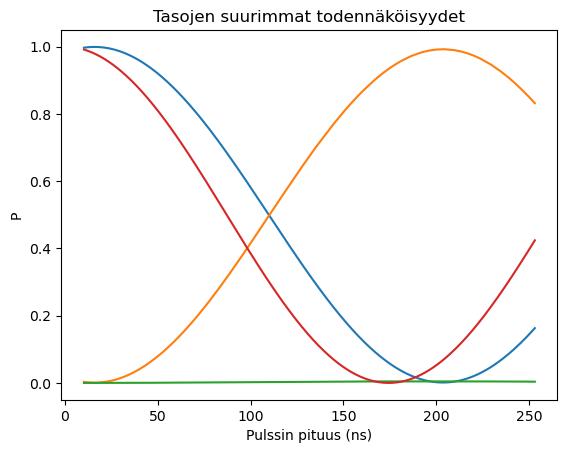

---------------------------------------------


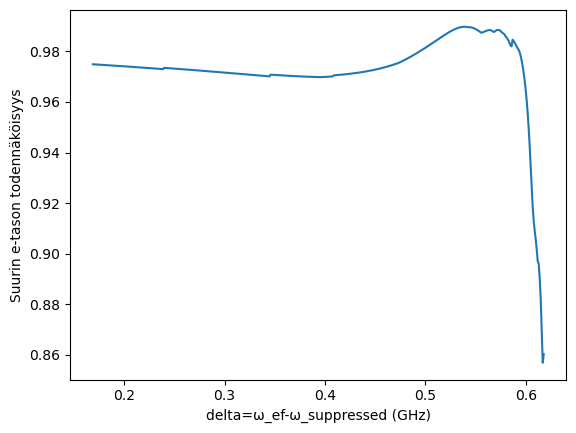

Amplitudi (GHz): 6.720941734809321
AC-stark siirtymä (GHz): 0.5387388599397027
E-tason suurin todennäköisyys: 0.9900098821131736
Pulssin pituus (ns): 171.0925573596138
Rabi-taajuus (fourier):  0.0030943843508843823


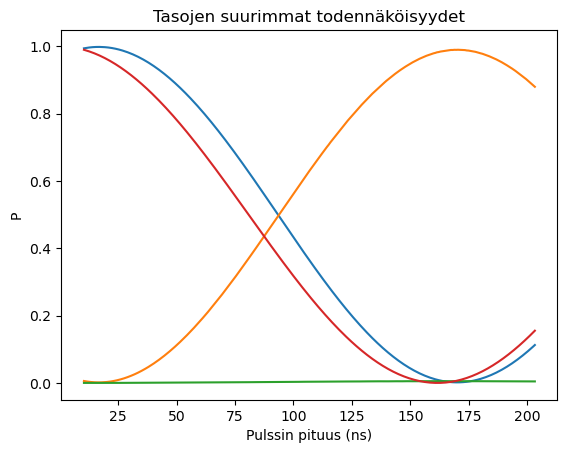

---------------------------------------------


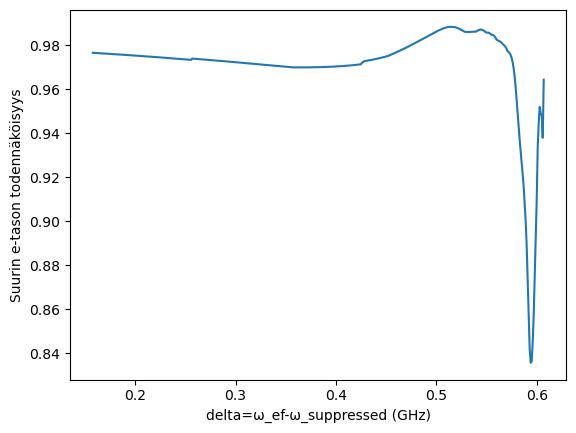

Amplitudi (GHz): 7.1502234424218925
AC-stark siirtymä (GHz): 0.5148532220176467
E-tason suurin todennäköisyys: 0.988902240464466
Pulssin pituus (ns): 145.1289417925606
Rabi-taajuus (fourier):  0.0037950125879155543


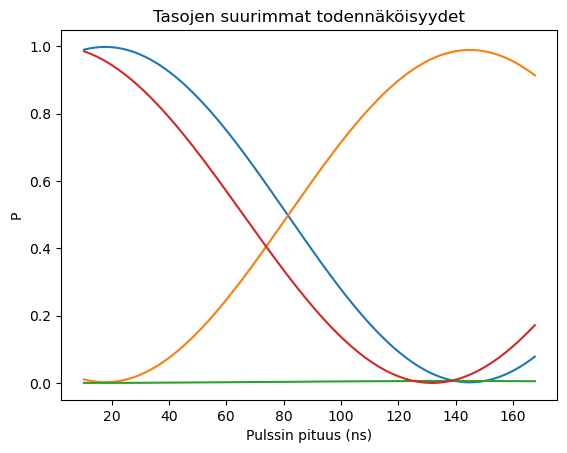

---------------------------------------------


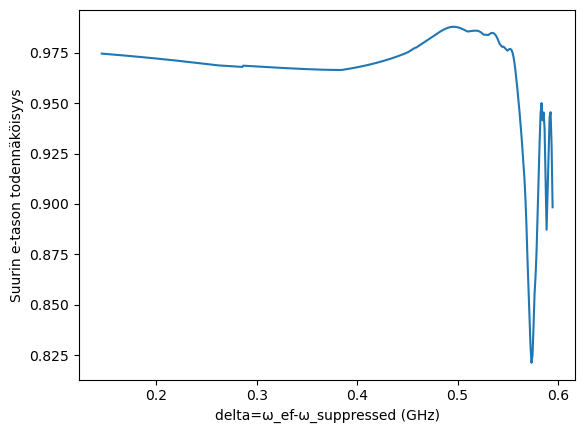

Amplitudi (GHz): 7.579505150034464
AC-stark siirtymä (GHz): 0.4966624934158271
E-tason suurin todennäköisyys: 0.987867396477707
Pulssin pituus (ns): 126.5961170954951
Rabi-taajuus (fourier):  0.00457028995807121


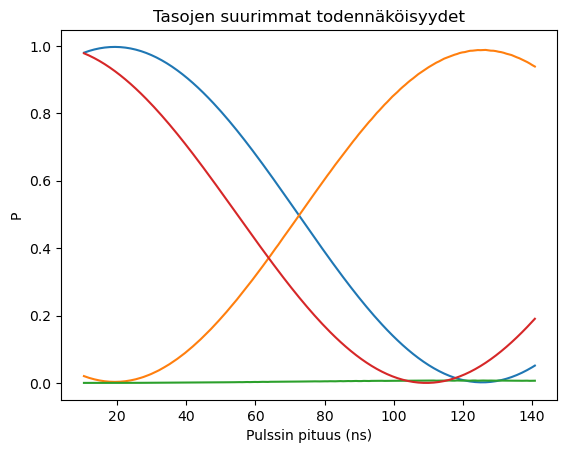

---------------------------------------------


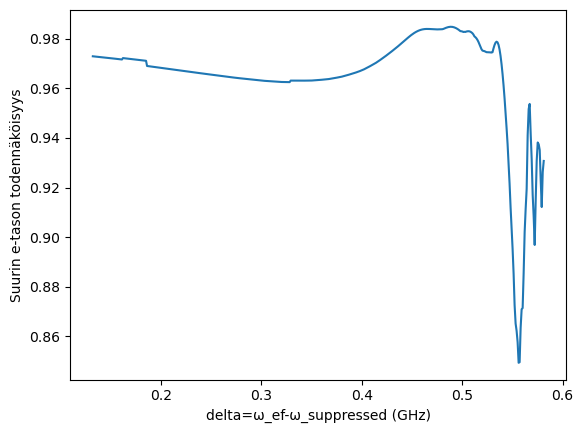

Amplitudi (GHz): 8.008786857647035
AC-stark siirtymä (GHz): 0.4891666741342439
E-tason suurin todennäköisyys: 0.9848226670267327
Pulssin pituus (ns): 107.26384305756297
Rabi-taajuus (fourier):  0.005434878167308393


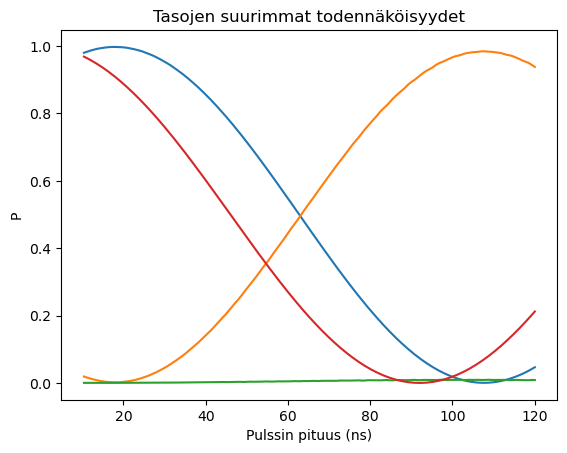

---------------------------------------------


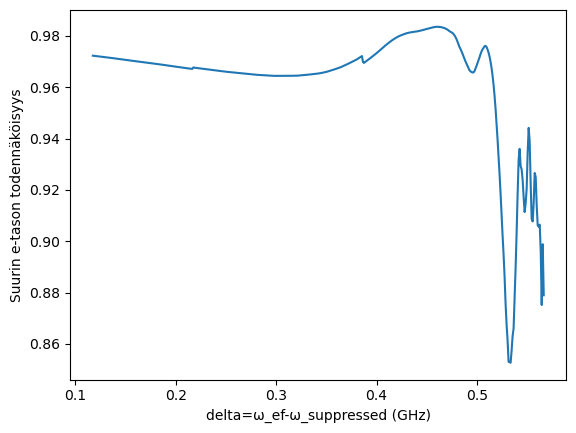

Amplitudi (GHz): 8.438068565259606
AC-stark siirtymä (GHz): 0.46036576417289726
E-tason suurin todennäköisyys: 0.983661743221769
Pulssin pituus (ns): 94.64805741781689
Rabi-taajuus (fourier):  0.006405663181360428


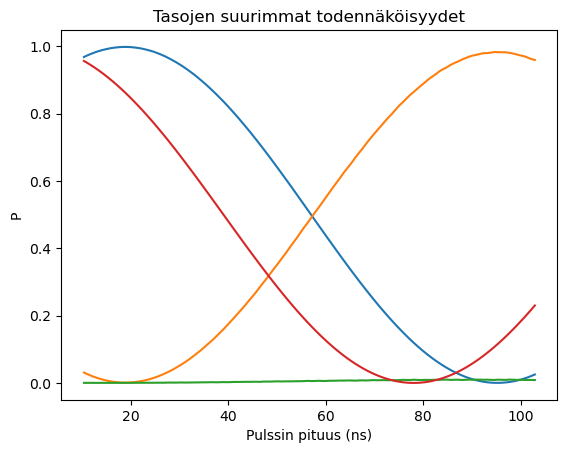

---------------------------------------------


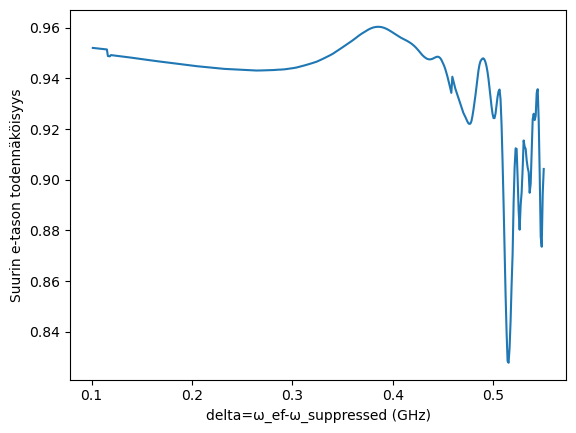

Amplitudi (GHz): 8.867350272872178
AC-stark siirtymä (GHz): 0.3852597635317868
E-tason suurin todennäköisyys: 0.9719592085528528
Pulssin pituus (ns): 84.25719618398782
Rabi-taajuus (fourier):  0.007488342396110612


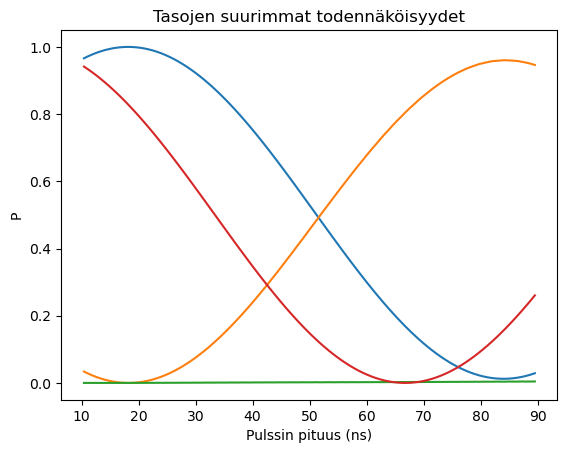

---------------------------------------------


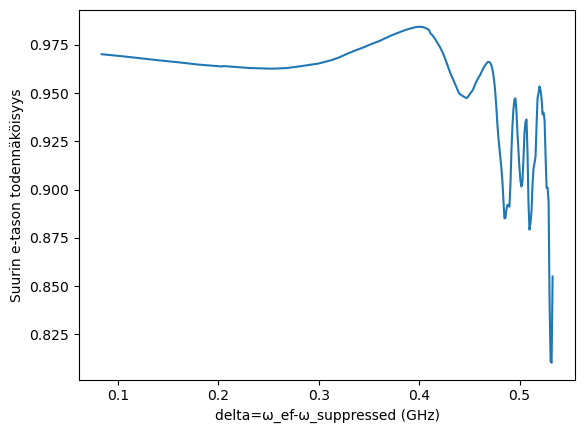

Amplitudi (GHz): 9.296631980484749
AC-stark siirtymä (GHz): 0.39984867221091297
E-tason suurin todennäköisyys: 0.9848732080768733
Pulssin pituus (ns): 75.3431164951781
Rabi-taajuus (fourier):  0.008700947820295287


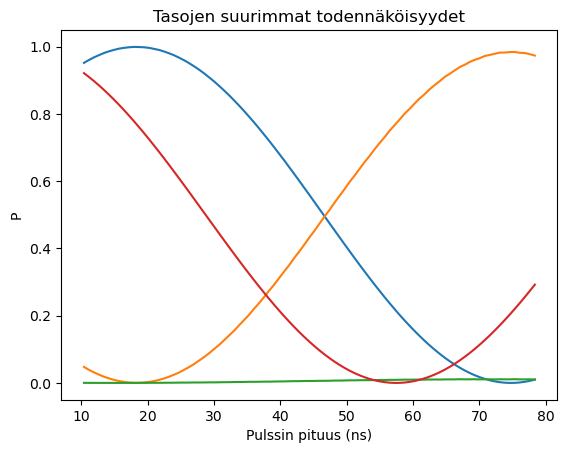

---------------------------------------------


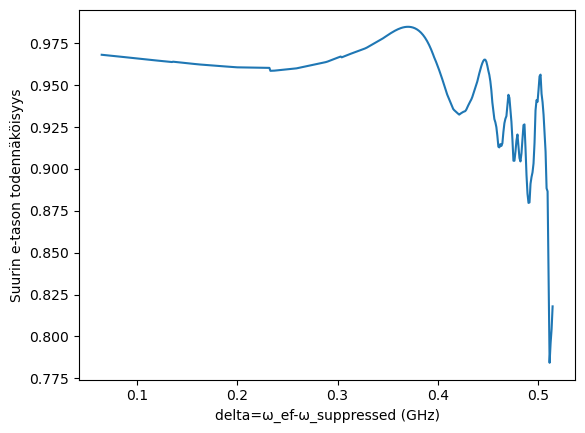

Amplitudi (GHz): 9.725913688097322
AC-stark siirtymä (GHz): 0.3701324902102753
E-tason suurin todennäköisyys: 0.9850117995691181
Pulssin pituus (ns): 66.3999733949929
Rabi-taajuus (fourier):  0.01005977195966383


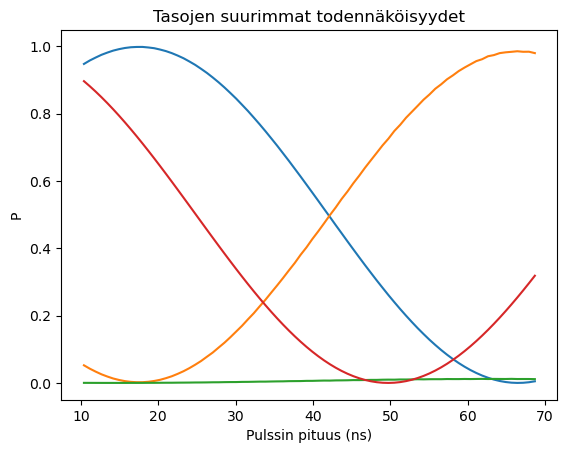

---------------------------------------------


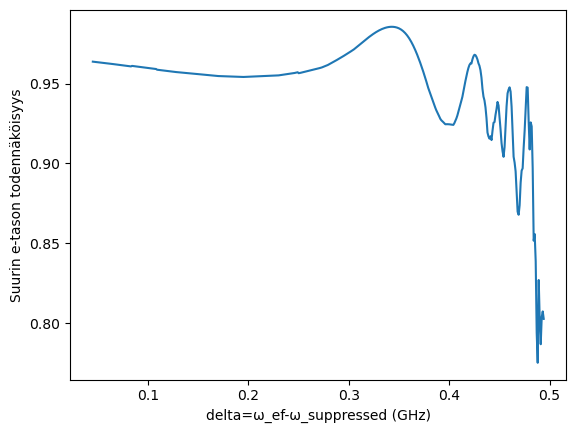

Amplitudi (GHz): 10.155195395709892
AC-stark siirtymä (GHz): 0.34311121752987417
E-tason suurin todennäköisyys: 0.9868962372076745
Pulssin pituus (ns): 58.18317582818186
Rabi-taajuus (fourier):  0.01156319637576678


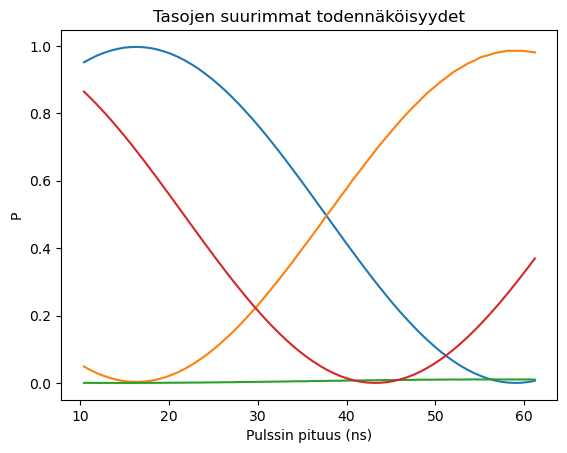

---------------------------------------------


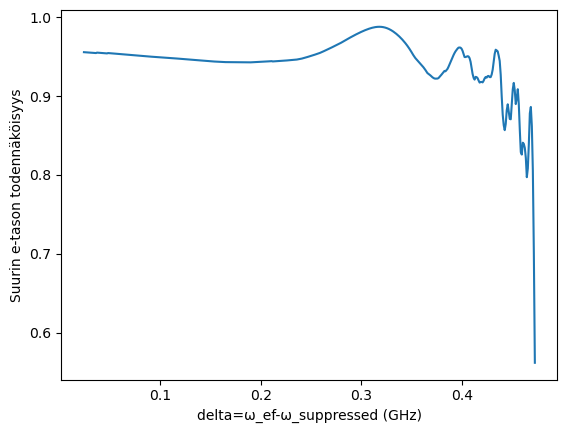

Amplitudi (GHz): 10.584477103322463
AC-stark siirtymä (GHz): 0.31778485416970953
E-tason suurin todennäköisyys: 0.988718699850082
Pulssin pituus (ns): 52.215401017846425
Rabi-taajuus (fourier):  0.013238831225432481


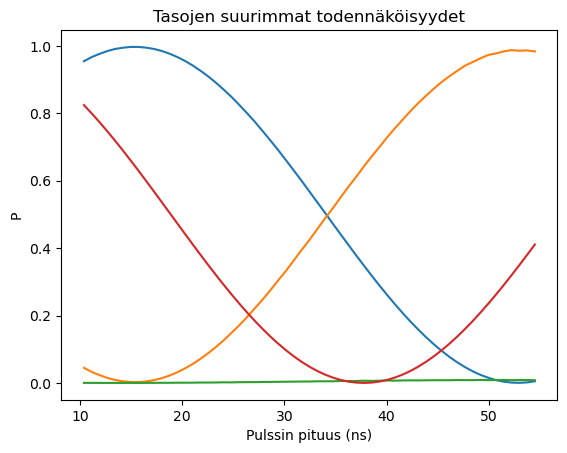

---------------------------------------------


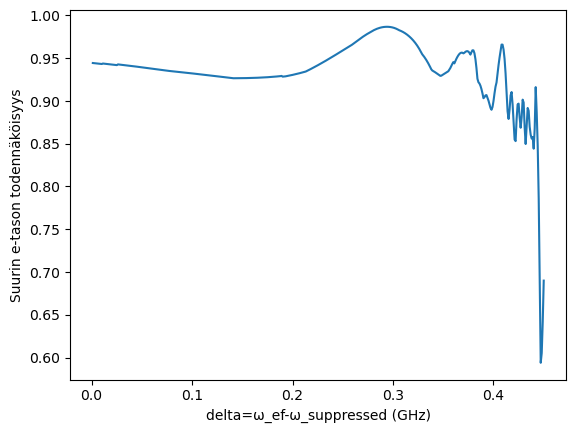

Amplitudi (GHz): 11.013758810935034
AC-stark siirtymä (GHz): 0.2941534001297812
E-tason suurin todennäköisyys: 0.9874038546800256
Pulssin pituus (ns): 48.51054014286148
Rabi-taajuus (fourier):  0.015106432960105422


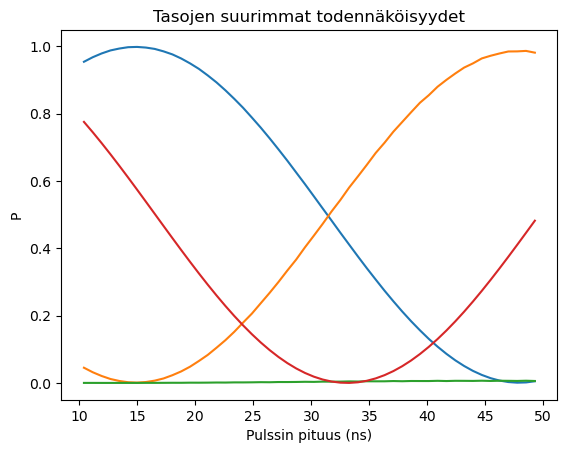

---------------------------------------------


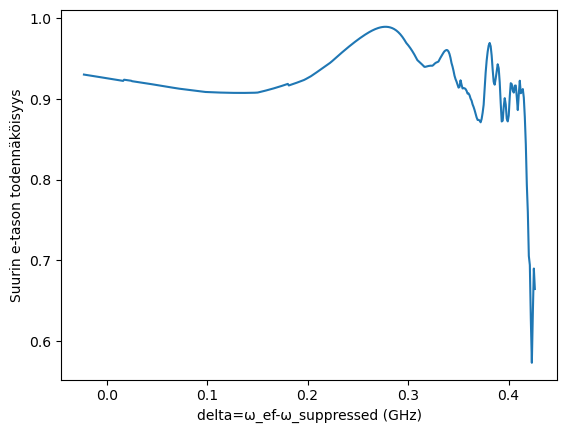

Amplitudi (GHz): 11.443040518547605
AC-stark siirtymä (GHz): 0.2772168554100892
E-tason suurin todennäköisyys: 0.9895983980123215
Pulssin pituus (ns): 43.26144511857313
Rabi-taajuus (fourier):  0.01717667788299274


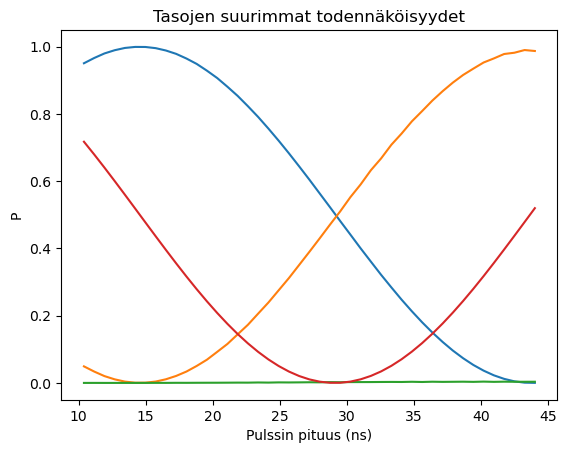

---------------------------------------------


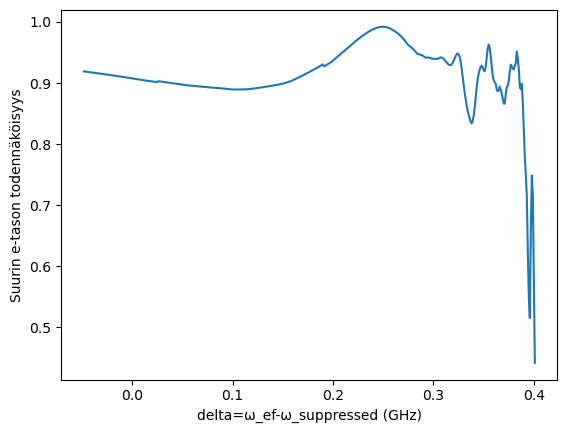

Amplitudi (GHz): 11.872322226160177
AC-stark siirtymä (GHz): 0.2499752200106336
E-tason suurin todennäköisyys: 0.9924172007859703
Pulssin pituus (ns): 40.28880760502594
Rabi-taajuus (fourier):  0.01942390099114799


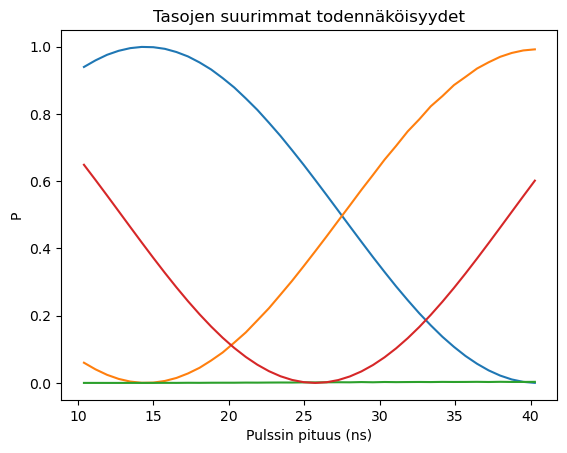

---------------------------------------------


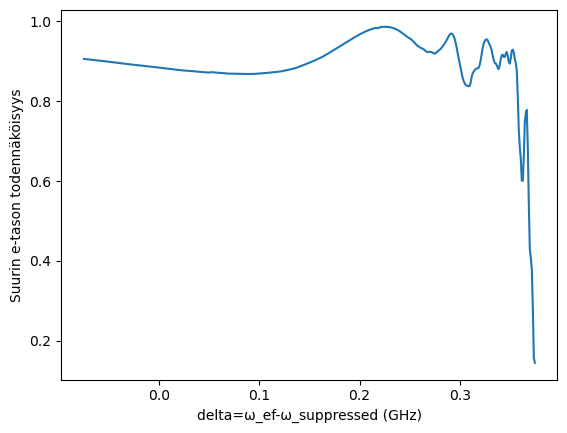

Amplitudi (GHz): 12.30160393377275
AC-stark siirtymä (GHz): 0.2244284939314144
E-tason suurin todennäköisyys: 0.9923062261626031
Pulssin pituus (ns): 36.53413079124889
Rabi-taajuus (fourier):  0.021923914266464898


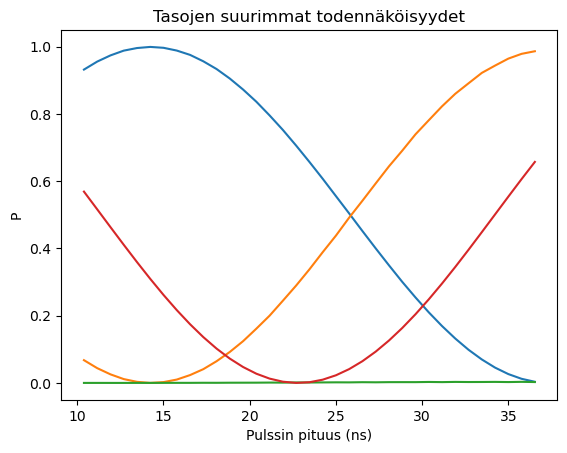

---------------------------------------------


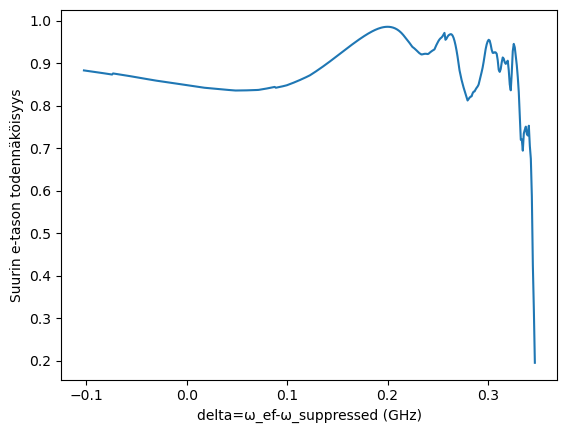

Amplitudi (GHz): 12.73088564138532
AC-stark siirtymä (GHz): 0.19957667717243177
E-tason suurin todennäköisyys: 0.9919189997939639
Pulssin pituus (ns): 33.53074595538659
Rabi-taajuus (fourier):  0.02462397758463905


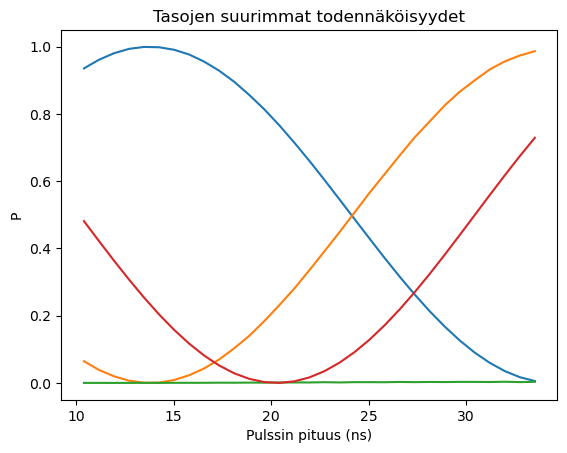

---------------------------------------------


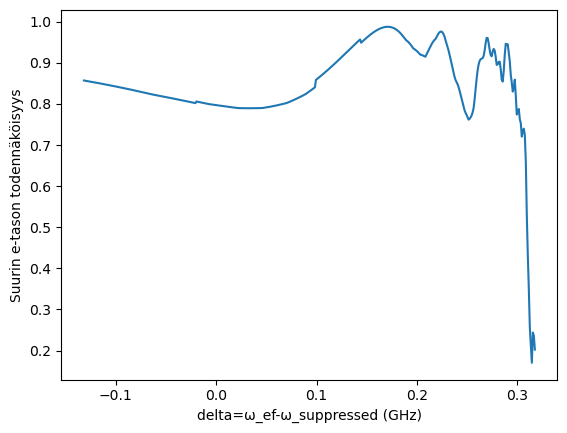

Amplitudi (GHz): 13.160167348997891
AC-stark siirtymä (GHz): 0.1714197697336854
E-tason suurin todennäköisyys: 0.9923714818648205
Pulssin pituus (ns): 31.28557389937458
Rabi-taajuus (fourier):  0.027602618982877018


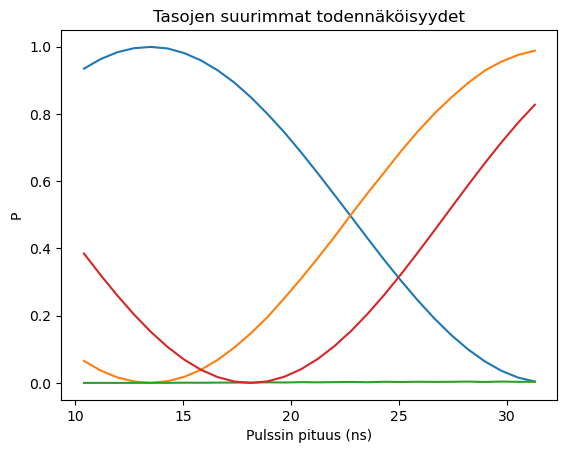

---------------------------------------------


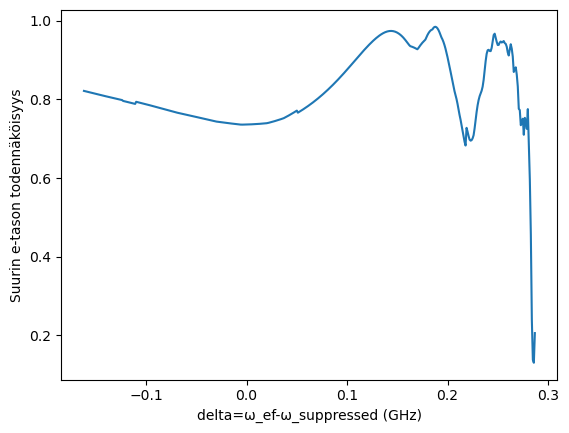

Amplitudi (GHz): 13.589449056610464
AC-stark siirtymä (GHz): 0.18795777161517535
E-tason suurin todennäköisyys: 0.986833665825284
Pulssin pituus (ns): 23.593261475004383
Rabi-taajuus (fourier):  0.03079836865015524


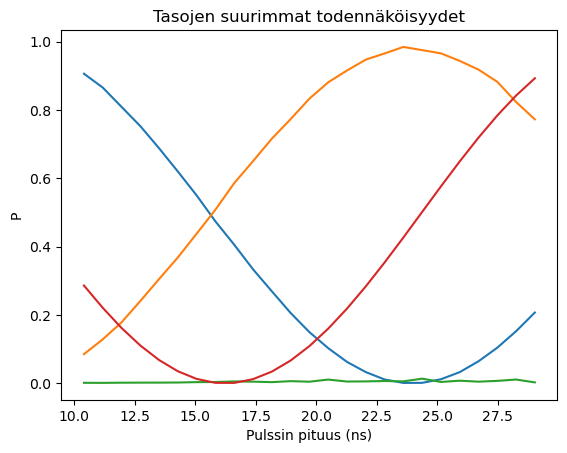

---------------------------------------------


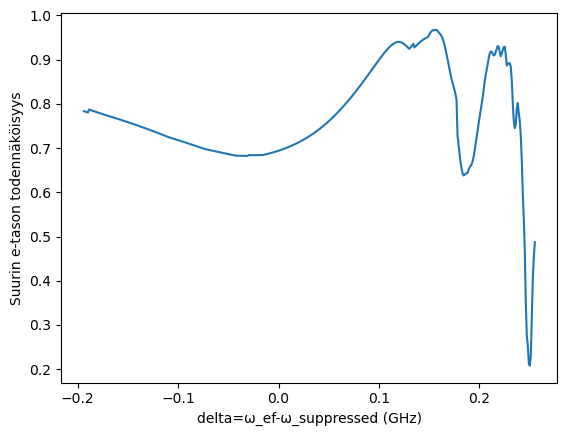

Amplitudi (GHz): 14.018730764223035
AC-stark siirtymä (GHz): 0.1561906828169018
E-tason suurin todennäköisyys: 0.9765275186136254
Pulssin pituus (ns): 22.86170599708851
Rabi-taajuus (fourier):  0.03423876746493767


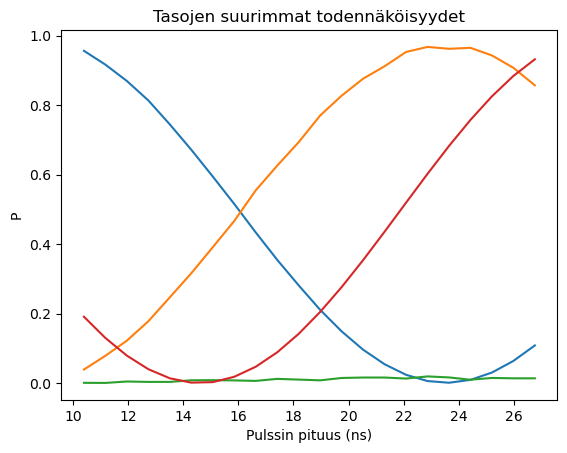

---------------------------------------------


In [7]:
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals = [] #Ajavan amplitudin arvot

#Määritellään rajat amplitudille sekä simulaatioiden määrä
min_range = 0.23
max_range = 0.55
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)

    f_d_opt = qubit.frequency/3+list_AC_stark_vals[i]

    f_rabi=2.875e-05*A**3 - 0.0003995*A**2 + 0.003097*A - 0.008257 #Arvaus Rabi-taajuudelle
    AC_stark=-0.003541*A**2 + 0.02376 *A + 0.469 #Arvaus AC-stark siirtymälle

    params=find_params(f_d_opt, A, evolution_eigenbasis,f_rabi*10,AC_stark,[-300,150],1000)
    deltas.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])
    
    f_supp_opt = f_ef/3+deltas[-1]

    m=10
    vals = sim_pulse(f_d_opt,f_ef/3+deltas[-1],A,evolution_eigenbasis,dim,(10*f_rabi)/m,t_ramp=5)

    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])

    max_vals.append([vals[0],vals[1]])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])
    
    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    #Taajuusavaruus
    freqs = np.fft.rfftfreq(len(g_vals), d=vals[4][1]-vals[4][0]) 

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[np.float64(5.862378319584177), np.float64(6.291660027196749), np.float64(6.720941734809321), np.float64(7.1502234424218925), np.float64(7.579505150034464), np.float64(8.008786857647035), np.float64(8.438068565259606), np.float64(8.867350272872178), np.float64(9.296631980484749), np.float64(9.725913688097322), np.float64(10.155195395709892), np.float64(10.584477103322463), np.float64(11.013758810935034), np.float64(11.443040518547605), np.float64(11.872322226160177), np.float64(12.30160393377275), np.float64(12.73088564138532), np.float64(13.160167348997891), np.float64(13.589449056610464), np.float64(14.018730764223035)]


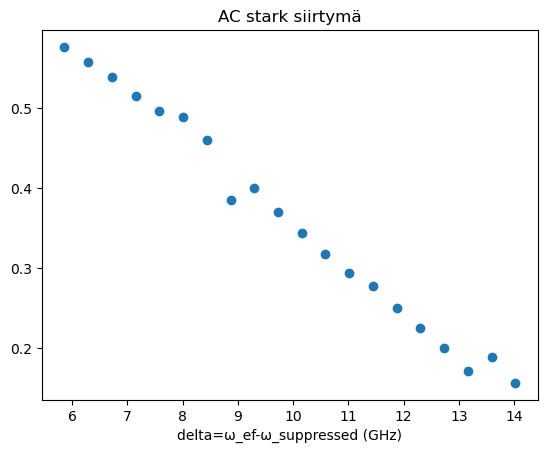

[np.float64(0.5765948637445237), np.float64(0.557319407181995), np.float64(0.5387388599397027), np.float64(0.5148532220176467), np.float64(0.4966624934158271), np.float64(0.4891666741342439), np.float64(0.46036576417289726), np.float64(0.3852597635317868), np.float64(0.39984867221091297), np.float64(0.3701324902102753), np.float64(0.34311121752987417), np.float64(0.31778485416970953), np.float64(0.2941534001297812), np.float64(0.2772168554100892), np.float64(0.2499752200106336), np.float64(0.2244284939314144), np.float64(0.19957667717243177), np.float64(0.1714197697336854), np.float64(0.18795777161517535), np.float64(0.1561906828169018)]


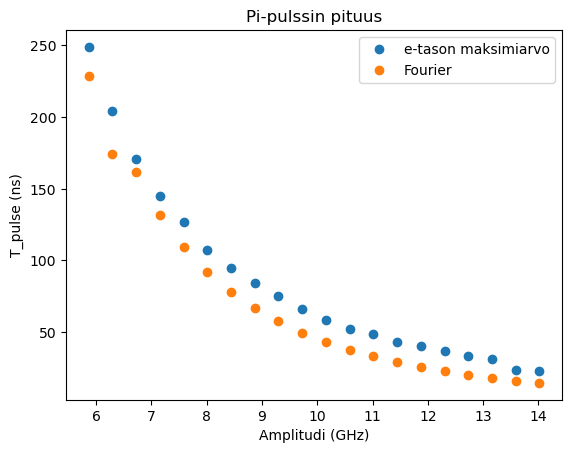

[np.float64(248.9538826788503), np.float64(204.46645373082308), np.float64(171.0925573596138), np.float64(145.1289417925606), np.float64(126.5961170954951), np.float64(107.26384305756297), np.float64(94.64805741781689), np.float64(84.25719618398782), np.float64(75.3431164951781), np.float64(66.3999733949929), np.float64(58.18317582818186), np.float64(52.215401017846425), np.float64(48.51054014286148), np.float64(43.26144511857313), np.float64(40.28880760502594), np.float64(36.53413079124889), np.float64(33.53074595538659), np.float64(31.28557389937458), np.float64(23.593261475004383), np.float64(22.86170599708851)]


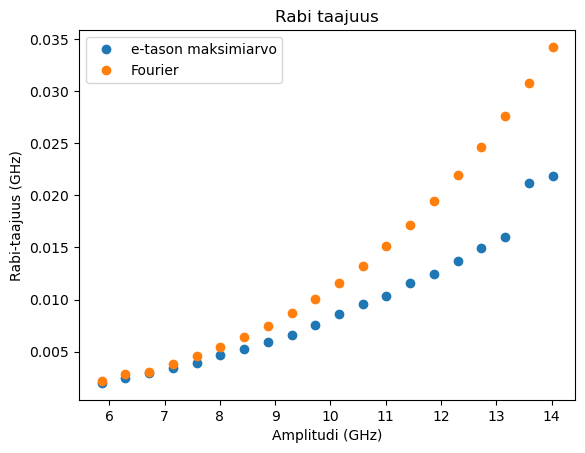

[np.float64(0.0021855491816959614), np.float64(0.0028685531735190067), np.float64(0.0030943843508843823), np.float64(0.0037950125879155543), np.float64(0.00457028995807121), np.float64(0.005434878167308393), np.float64(0.006405663181360428), np.float64(0.007488342396110612), np.float64(0.008700947820295287), np.float64(0.01005977195966383), np.float64(0.01156319637576678), np.float64(0.013238831225432481), np.float64(0.015106432960105422), np.float64(0.01717667788299274), np.float64(0.01942390099114799), np.float64(0.021923914266464898), np.float64(0.02462397758463905), np.float64(0.027602618982877018), np.float64(0.03079836865015524), np.float64(0.03423876746493767)]


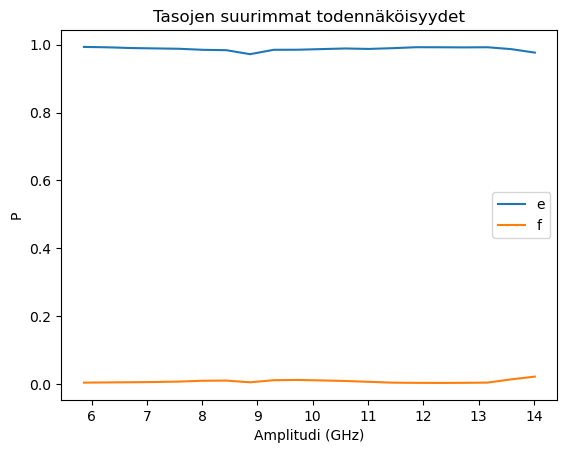

[np.float64(0.9933070518626157), np.float64(0.9921466968670011), np.float64(0.9900098821131736), np.float64(0.988902240464466), np.float64(0.987867396477707), np.float64(0.9848226670267327), np.float64(0.983661743221769), np.float64(0.9719592085528528), np.float64(0.9848732080768733), np.float64(0.9850117995691181), np.float64(0.9868962372076745), np.float64(0.988718699850082), np.float64(0.9874038546800256), np.float64(0.9895983980123215), np.float64(0.9924172007859703), np.float64(0.9923062261626031), np.float64(0.9919189997939639), np.float64(0.9923714818648205), np.float64(0.986833665825284), np.float64(0.9765275186136254)]
[np.float64(0.00408762709810676), np.float64(0.004716322502172704), np.float64(0.00524825607109991), np.float64(0.005909052452528597), np.float64(0.007224525862156227), np.float64(0.009647911372858654), np.float64(0.010156609031400478), np.float64(0.0051092173001440755), np.float64(0.011249247562224549), np.float64(0.012061739189874483), np.float64(0.01063654250

In [8]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.xlabel("delta=ω_ef-ω_suppressed (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.plot(A_vals, 1/(2*np.array(rabis)), 'o')
plt.legend(["e-tason maksimiarvo","Fourier"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, 1/(2*np.array(pulse_lengths)), 'o')
plt.plot(A_vals, rabis, 'o')
plt.legend(["e-tason maksimiarvo","Fourier"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(A_vals, e_vals)
plt.plot(A_vals, f_vals)
plt.legend(["e","f"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)